In [16]:
## Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## sklearn -- datasets
from sklearn import datasets

## skelarn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict

## sklearn -- models
from sklearn.linear_model import SGDClassifier


## sklearn -- metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, classification_report
from sklearn.metrics import confusion_matrix

In [2]:
## Load dataset
mnist_dataset = datasets.fetch_openml('mnist_784', version=1)

C:\Users\moham\anaconda3\envs\base_new\lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [3]:
## Features
X = mnist_dataset['data']

## Label
y = mnist_dataset['target'].astype(int)

In [ ]:
y

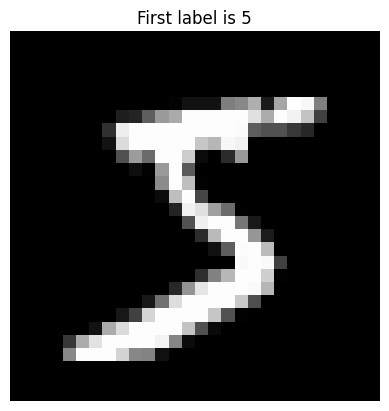

In [4]:
## Check first image
first_image = X.iloc[0, :].values.reshape(28, 28)

## Plotting
plt.imshow(first_image, cmap='gray')
plt.title(f'First label is {y.iloc[0]}')
plt.axis('off')
plt.show()

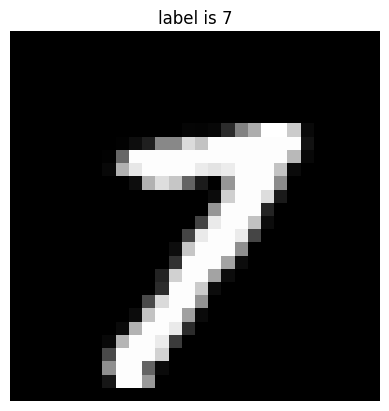

In [5]:
## Check image i = 40000
i = 40000
val_image = X.iloc[i, :].values.reshape(28, 28)

## Plotting
plt.imshow(val_image, cmap='gray')
plt.title(f'label is {y.iloc[i]}')
plt.axis('off')
plt.show()

* `Preprocessing`

In [6]:
X.max(axis=None), X.min(axis=None)

(255.0, 0.0)

In [7]:
## Normalization
X_new = X / 255.

X_new.max(axis=None), X_new.min(axis=None)

(1.0, 0.0)

* `Split Dataset`

In [8]:
## Split for Train (use cross validation) and test 
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)

## check the shapes
print('X_train shape -- ', X_train.shape)
print('y_train shape -- ', y_train.shape)
print('X_test shape -- ', X_test.shape)
print('y_test shape -- ', y_test.shape)

X_train shape --  (56000, 784)
y_train shape --  (56000,)
X_test shape --  (14000, 784)
y_test shape --  (14000,)


* `Models`

In [9]:
## Slicing for simiplicity
X_train_new = X_train.iloc[:5000]
y_train_new = y_train.iloc[:5000]

In [10]:
## SGD
sgd_clf = SGDClassifier(random_state=42, penalty=None)

In [11]:
## Cross Validation
scores_sgd = cross_val_score(estimator=sgd_clf, X=X_train_new, y=y_train_new, cv=5, n_jobs=-1, scoring='accuracy')

In [13]:
scores_sgd.mean()

0.8634000000000001

In [14]:
## Predict
y_pred_sgd = cross_val_predict(estimator=sgd_clf, X=X_train_new, y=y_train_new, cv=5, n_jobs=-1, method='predict')

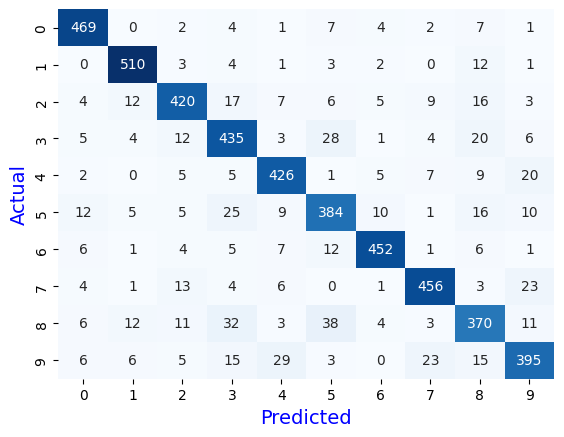

In [22]:
## Evaluate 
## Check confusion matrix
conf_sgd = confusion_matrix(y_train_new, y_pred_sgd)

## as a heatmap
sns.heatmap(conf_sgd, fmt='.0f', annot=True, cbar=False, cmap='Blues')
plt.xlabel('Predicted', fontsize=14, color='b')
plt.ylabel('Actual', fontsize=14, color='b')
plt.show()

In [24]:
## precision
precision_score(y_train_new, y_pred_sgd, average='macro')  ## Multiclass (try, micro, macro, weighted)

0.8626580626224403

In [25]:
## Recall
recall_score(y_train_new, y_pred_sgd, average='macro')  ## Multiclass (try, micro, macro, weighted)

0.8624507533871302

In [26]:
## f1-score
f1_score(y_train_new, y_pred_sgd, average='macro')  ## Multiclass (try, micro, macro, weighted)

0.8623118634837479

In [28]:
print(classification_report(y_train_new, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       497
           1       0.93      0.95      0.94       536
           2       0.88      0.84      0.86       499
           3       0.80      0.84      0.82       518
           4       0.87      0.89      0.88       480
           5       0.80      0.81      0.80       477
           6       0.93      0.91      0.92       495
           7       0.90      0.89      0.90       511
           8       0.78      0.76      0.77       490
           9       0.84      0.79      0.82       497

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



In [33]:
sum(y_train_new==5)

477